In [1]:
#Install required packages

%pip install -q langgraph langchain_openai langsmith langgraph-supervisor openai

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment Variable Initialization

import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())  # loads .env from the notebook's working directory

def _set_if_undefined(var_name: str):
    value = os.environ.get(var_name, "").strip()
    if value:
        masked = value[:6] + "*" * (min(20, len(value) - 6))
        print(f"  ✅ {var_name}: {masked}")
    else:
        print(f"  ❌ {var_name}: not set")

# ---- Environment Variables Required ----

print("Checking environment variables...")
_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGSMITH_TRACING") 
_set_if_undefined("LANGSMITH_API_KEY") # https://docs.langchain.com/langsmith/observability
_set_if_undefined("MODEL")
_set_if_undefined("OPENWEATHER_API_KEY") # https://openweathermap.org/api
print("Done.")

Checking environment variables...
  ✅ OPENAI_API_KEY: sk-pro********************
  ✅ LANGSMITH_TRACING: true
  ✅ LANGSMITH_API_KEY: lsv2_p********************
  ✅ MODEL: gpt-4o*****
  ✅ OPENWEATHER_API_KEY: 8dd1b8********************
Done.


In [3]:
import os, warnings
import requests
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, ToolMessage, HumanMessage, RemoveMessage
from langgraph.warnings import LangGraphDeprecatedSinceV10
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langchain_core.tools import tool
from openai import OpenAI
from pydantic import BaseModel
from typing import Annotated

warnings.filterwarnings("ignore", category=LangGraphDeprecatedSinceV10)

default_model = os.environ["MODEL"]
llm = ChatOpenAI(model=default_model)
openai_client = OpenAI()

def _trim(system_text, state, keep):
    msgs = list(state["messages"])
    recent = msgs[-keep:] if len(msgs) > keep else msgs
    while recent and isinstance(recent[0], ToolMessage):
        recent = recent[1:]
    if not recent:
        recent = msgs[-1:]
    return [SystemMessage(content=system_text)] + recent

@tool
def weather_reporting_tool(city: Annotated[str, "name of the city"]):
    "Fetch current weather data for a city from OpenWeatherMap (temperatures in Celsius)."
    resp = requests.get(
        "https://api.openweathermap.org/data/2.5/weather",
        params={"q": city, "appid": os.environ["OPENWEATHER_API_KEY"], "units": "metric"},
        timeout=10,
    )
    resp.raise_for_status()
    data = resp.json()
    return {"weather": {
        "name": data["name"],
        "main": data["weather"][0]["main"],
        "description": data["weather"][0]["description"],
        "units": "metric (Celsius)",
        **data["main"],  # temp, feels_like, temp_min, temp_max, pressure, humidity
        "wind_speed": data.get("wind", {}).get("speed"),
    }}

# Holds the generated image out-of-band so the ~1MB base64 payload never
# re-enters the LLM conversation (that blob was ~600K tokens -> 429 RateLimitError).
LAST_IMAGE = {"data_url": None}

@tool
def dalle_image_generation_tool(prompt: Annotated[str, "image description"]) -> str:
    "Generate an image using gpt-image-1. Stashes the image; returns a short status string."
    # quality="low" is the biggest speed/cost lever for gpt-image-1.
    resp = openai_client.images.generate(model="gpt-image-1", prompt=prompt,
        n=1, size="1024x1024", quality="low", output_format="png")
    d = resp.data[0]
    LAST_IMAGE["data_url"] = d.url or f"data:image/png;base64,{d.b64_json}"
    # Return only a tiny confirmation to the LLM, NOT the base64 payload.
    return "Image generated successfully."

weather_agent = create_react_agent(
    llm, tools=[weather_reporting_tool], name="weather_reporting_agent",
    prompt=lambda s: _trim(
        "You are a weather reporter. Report current weather for the city. "
        "Use the weather_reporting_tool. Temperatures are in Celsius. Do not suggest clothing.", s, keep=4)
)
dressing_agent = create_react_agent(
    llm, tools=[], name="dressing_planner_agent",
    prompt=lambda s: _trim(
        "Based on the weather data provided, suggest appropriate clothing. "
        "Be specific about garments.", s, keep=6)
)
image_agent = create_react_agent(
    llm, tools=[dalle_image_generation_tool], name="image_generation_agent",
    prompt=lambda s: _trim(
        "Generate an image of a person wearing the suggested clothing. "
        "Call dalle_image_generation_tool with a detailed visual prompt. "
        "The tool returns only a status string; report success without echoing image data.", s, keep=6)
)

class FinalResponse(BaseModel):
    weather_summary: str
    dressing_suggestion: str
    image_status: str

def _supervisor_trim(state):
    msgs = list(state["messages"])
    recent = msgs[-8:] if len(msgs) > 8 else msgs
    while recent and isinstance(recent[0], ToolMessage):
        recent = recent[1:]
    if not recent:
        recent = msgs
    removes = [RemoveMessage(id=m.id) for m in msgs if m not in recent]
    return {"messages": removes + recent}

supervisor = create_supervisor(
    agents=[weather_agent, dressing_agent, image_agent],
    model=llm,
    prompt=(
        "You manage three workers: weather_reporting_agent, dressing_planner_agent, image_generation_agent.\n"
        "Steps (do each ONCE, in order):\n"
        "1. Call weather_reporting_agent with the city name.\n"
        "2. Call dressing_planner_agent with the weather results.\n"
        "3. Call image_generation_agent with the clothing suggestion.\n"
        "4. Return FinalResponse. Stop. Do not repeat any step."
    ),
    response_format=FinalResponse,
    output_mode="last_message",
    pre_model_hook=_supervisor_trim,
)

graph = supervisor.compile()
print("Graph compiled OK")

Graph compiled OK


In [4]:
# Graph compiled in cell above.

_No structured response — showing last message._

FinalResponse: You have clothing suggestions suitable for the warm weather in Barcelona, which include a lightweight short-sleeve blouse, lightweight shorts, comfortable sandals, a wide-brimmed hat, and sunglasses. An image has also been generated to visualize these suggestions.

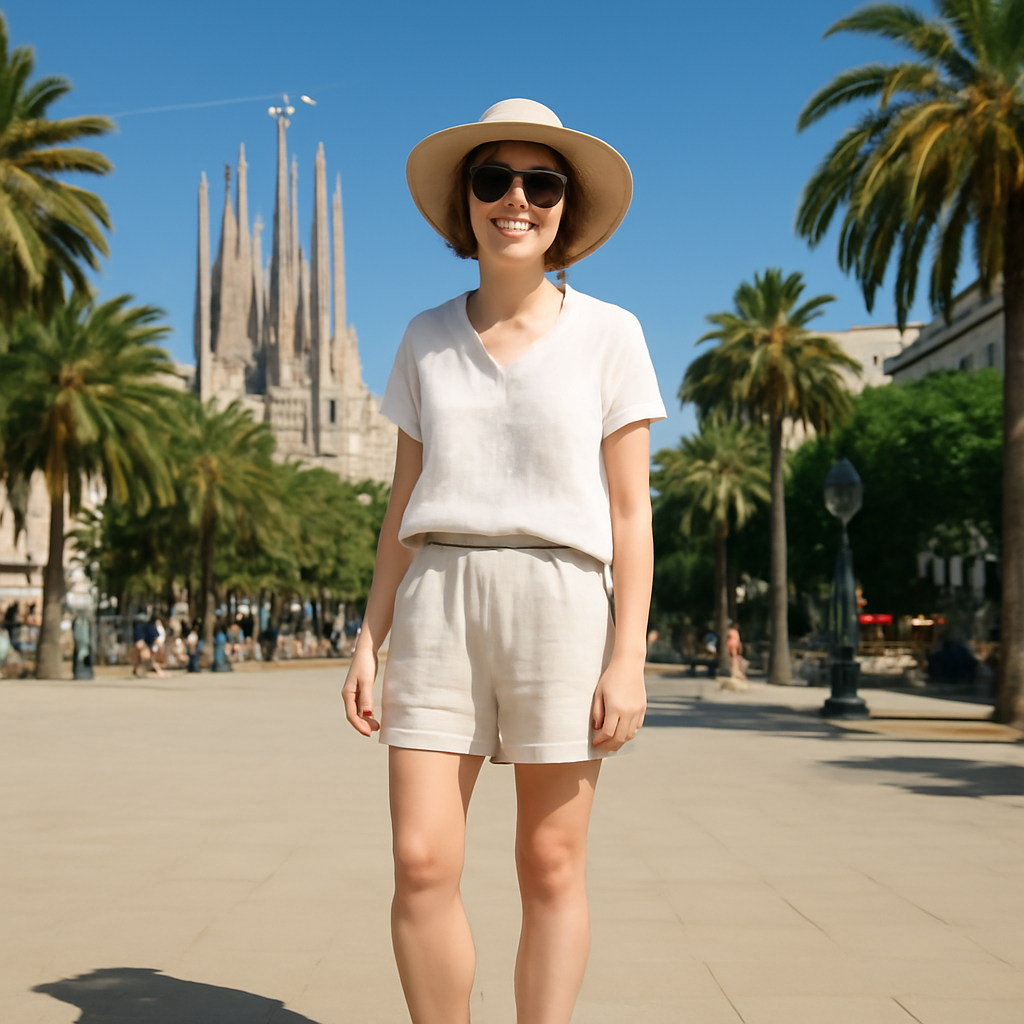

In [7]:
from IPython.display import display, Image, Markdown
import base64

# Provide a real city — the weather tool now calls a live API, so an empty
# string would 404. Change this to any city you like.
result = graph.invoke(
    {"messages": [("user", "Barcelona")]}
)

final = result.get("structured_response")
if final:
    display(Markdown(f"### Weather\n{final.weather_summary}"))
    display(Markdown(f"### Dressing Suggestion\n{final.dressing_suggestion}"))
else:
    # Structured parse can fail if the supervisor emits plain text instead of a
    # FinalResponse object; fall back to the last message so we still show text.
    display(Markdown("_No structured response — showing last message._"))
    display(Markdown(result["messages"][-1].content))

# Image lives out-of-band in LAST_IMAGE, so show it regardless of parse outcome.
img = LAST_IMAGE["data_url"]
if img and img.startswith("data:image"):
    display(Image(data=base64.b64decode(img.split(",", 1)[1])))
elif img:
    display(Image(url=img))
else:
    display(Markdown("_No image returned._"))